<a href="https://colab.research.google.com/github/morozovsolncev/ontology_of_synthesis/blob/main/orbita_18_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


ВВОД ПАРАМЕТРОВ МОДЕЛИ
(Нажмите Enter для использования значений по умолчанию)

Число вершин центрального кластера [200]: 
Число вершин пробного кластера [800]: 
Плотность связей в центре (p_center) [1.6]: 
Сила гравитации (p_inter) [0.06]: 
Начальное расстояние пробного тела [6.0]: 
Число шагов симуляции [400]: 5000
Шаг времени dt [0.05]: 
Seed для воспроизводимости [45]: 

--- ОПЦИОНАЛЬНЫЕ ВЫВОДЫ ---
Показывать фрагмент кластера с треугольниками? (y/n) [n]: n
Создавать анимацию? (y/n) [y]: n

ЗАПУСК МОДЕЛИ

УЧЕБНАЯ ДЕМОНСТРАЦИЯ ОНТОЛОГИЧЕСКОЙ ГРАВИТАЦИИ

[ОНТОЛОГИЯ]
  • Беспредельное поле потенций (БПП) — состояние чистой возможности
  • Вершины — акты различения, минимальные единицы бытия
  • Связи — установленные отношения, результат резонанса
  • Треугольники — кванты пространственности

[РЕЗОНАНС]
  • Резонанс — процесс зондирования: пробные связи возникают и исчезают
  • Цвет линий: зелёный (высокая вероятность), жёлтый, оранжевый (низкая)
  • Красная линия — основной резонанс,

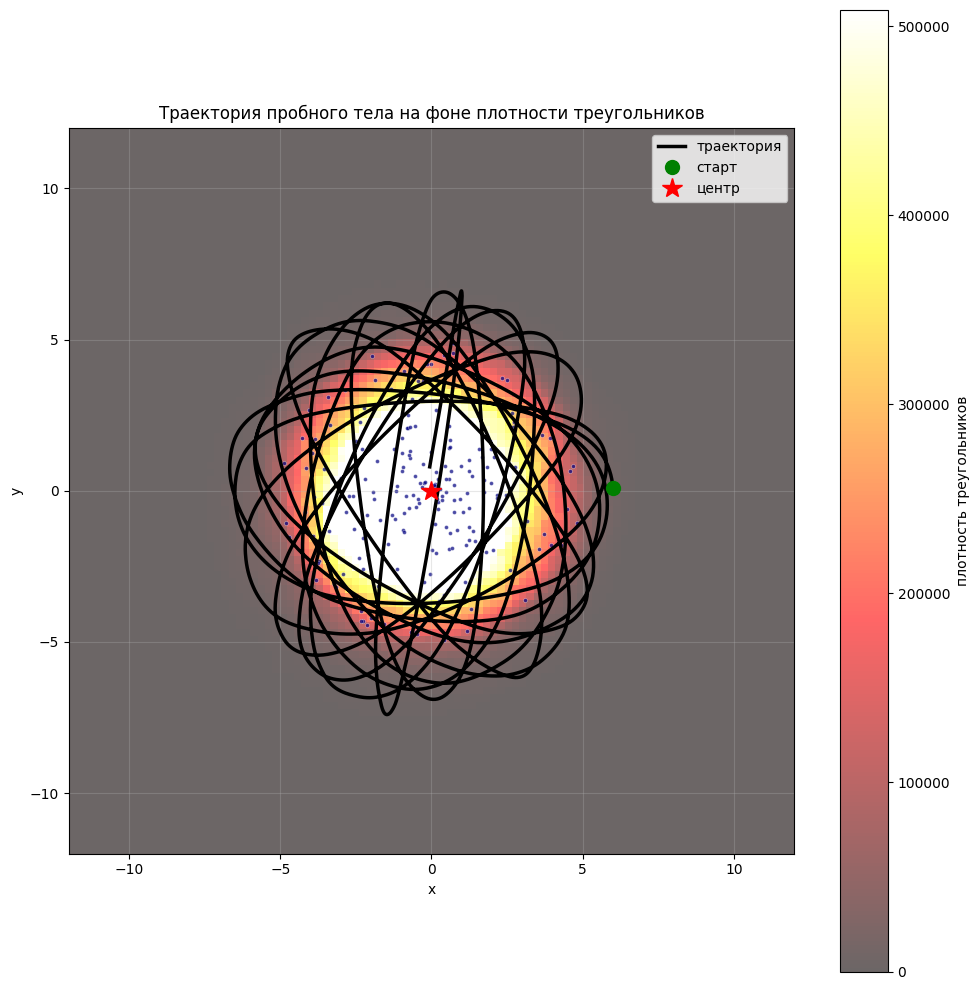

  Сохранено: trajectory_static.png


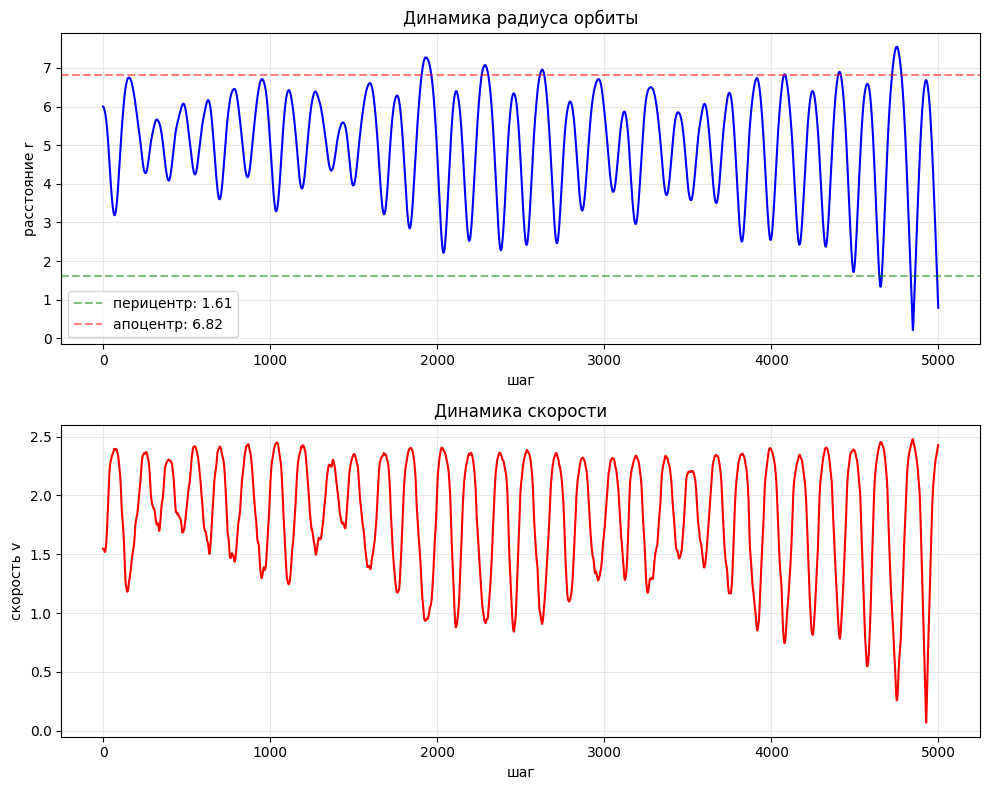

  Сохранено: radius_velocity.png


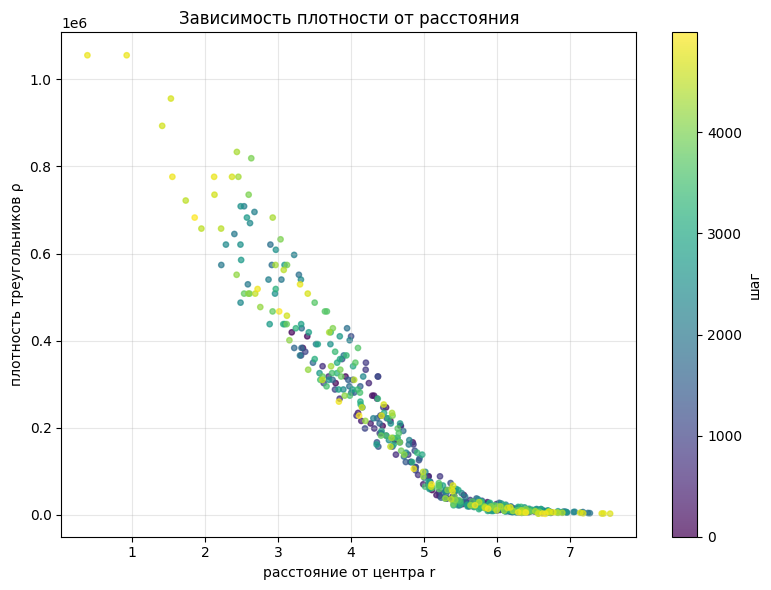

  Сохранено: density_profile.png


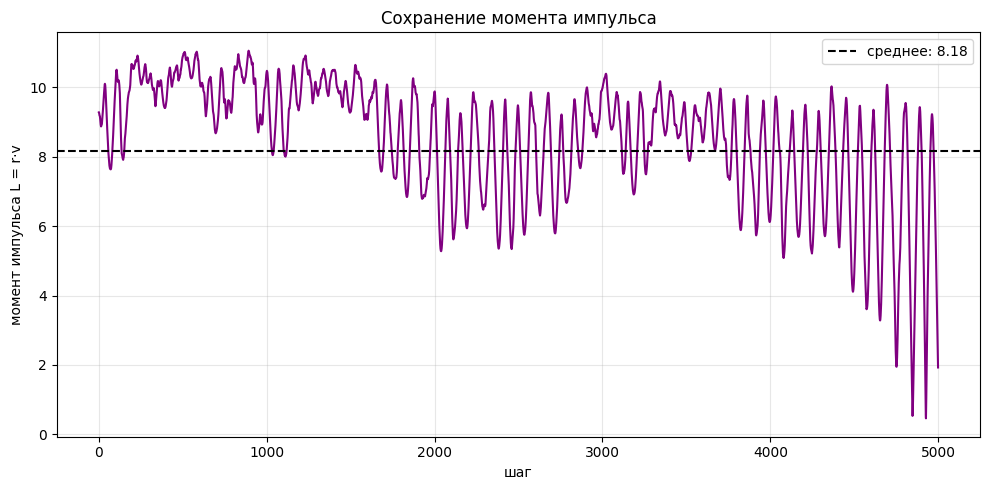

  Сохранено: angular_momentum.png

[АНИМАЦИЯ] Пропущена по запросу

ДЕМОНСТРАЦИЯ ЗАВЕРШЕНА

Созданы файлы:
  • trajectory_static.png — траектория на фоне плотности
  • radius_velocity.png — графики радиуса и скорости
  • density_profile.png — зависимость плотности от расстояния
  • angular_momentum.png — сохранение момента импульса


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
УЧЕБНАЯ ДЕМОНСТРАЦИЯ ОНТОЛОГИЧЕСКОЙ ГРАВИТАЦИИ
С запросом параметров и опциональными выводами orbita-18.ipynb
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.spatial import KDTree
from scipy.signal import find_peaks
import time
from IPython.display import display, Image

class OntologicalGravityDemo:
    def __init__(self, n_center=200, n_shell=800,
                 p_center=1.6, p_shell=0.01, p_inter=0.06,
                 center_radius=5.0, shell_radius=0.5, shell_orbit=6.0,
                 avg_radius=5.0, seed=45):

        self.print_intro()

        self.n_center = n_center
        self.n_shell = n_shell
        self.n_total = n_center + n_shell

        self.p_center = p_center
        self.p_shell = p_shell
        self.p_inter = p_inter
        self.avg_radius = avg_radius

        if seed is not None:
            np.random.seed(seed)

        self.positions = np.zeros((self.n_total, 2))

        print("\n[ЭТАП 1] Формирование центрального кластера из хаоса")

        # Центральный кластер
        for i in range(n_center):
            r = np.random.random() * center_radius
            theta = np.random.random() * 2 * np.pi
            self.positions[i] = [r * np.cos(theta), r * np.sin(theta)]

        # Пробный кластер
        self.shell_center = np.array([shell_orbit, 0.0])
        for i in range(n_center, self.n_total):
            r = np.random.random() * shell_radius
            theta = np.random.random() * 2 * np.pi
            local_pos = np.array([r * np.cos(theta), r * np.sin(theta)])
            self.positions[i] = self.shell_center + local_pos

        self.adj = np.zeros((self.n_total, self.n_total), dtype=bool)
        self.init_connections()

        self.kdtree_center = KDTree(self.positions[:n_center])
        self.kdtree_shell = KDTree(self.positions[n_center:])

        v_circular = np.sqrt(p_inter * 40)
        self.shell_velocity = np.array([0.0, v_circular])

        self.history = {'x': [], 'y': [], 'vx': [], 'vy': [], 'r': [], 'angle': []}

        # Данные о кластере
        self.cluster_data = self.analyze_cluster()

        print(f"\n[ЭТАП 2] Движение пробного тела")
        print(f"  Пробное тело запущено из точки ({shell_orbit}, 0) со скоростью {v_circular:.3f}")

    def print_intro(self):
        print("\n" + "="*70)
        print("УЧЕБНАЯ ДЕМОНСТРАЦИЯ ОНТОЛОГИЧЕСКОЙ ГРАВИТАЦИИ")
        print("="*70)
        print("\n[ОНТОЛОГИЯ]")
        print("  • Беспредельное поле потенций (БПП) — состояние чистой возможности")
        print("  • Вершины — акты различения, минимальные единицы бытия")
        print("  • Связи — установленные отношения, результат резонанса")
        print("  • Треугольники — кванты пространственности")
        print("\n[РЕЗОНАНС]")
        print("  • Резонанс — процесс зондирования: пробные связи возникают и исчезают")
        print("  • Цвет линий: зелёный (высокая вероятность), жёлтый, оранжевый (низкая)")
        print("  • Красная линия — основной резонанс, определяющий движение")

    def init_connections(self):
        center_indices = range(self.n_center)
        shell_indices = range(self.n_center, self.n_total)

        for i in center_indices:
            for j in center_indices:
                if i < j and np.random.random() < self.p_center:
                    self.adj[i][j] = self.adj[j][i] = True

        for i in shell_indices:
            for j in shell_indices:
                if i < j and np.random.random() < self.p_shell:
                    self.adj[i][j] = self.adj[j][i] = True

        for i in center_indices:
            for j in shell_indices:
                if np.random.random() < self.p_inter:
                    self.adj[i][j] = self.adj[j][i] = True

    def analyze_cluster(self):
        """Анализ структуры центрального кластера"""
        print("\n[АНАЛИЗ КЛАСТЕРА]")

        # Радиусы вершин
        radii = [np.linalg.norm(self.positions[i]) for i in range(self.n_center)]
        r_max = max(radii)
        r_mean = np.mean(radii)

        # Плотность в центре
        rho_center = self.count_triangles_in_region_center([0, 0], self.avg_radius)

        print(f"  Радиус кластера: {r_max:.2f}")
        print(f"  Средний радиус вершин: {r_mean:.2f}")
        print(f"  Плотность треугольников в центре: {rho_center:.0f}")

        return {'radii': radii, 'r_max': r_max, 'rho_center': rho_center}

    def count_triangles_in_region_center(self, center, radius):
        indices = self.kdtree_center.query_ball_point(center, radius)
        if len(indices) < 3:
            return 0

        triangles = 0
        for idx_i, i in enumerate(indices):
            for idx_j, j in enumerate(indices[idx_i+1:], start=idx_i+1):
                if self.adj[i][j]:
                    for k in indices[idx_j+1:]:
                        if self.adj[i][k] and self.adj[j][k]:
                            triangles += 1
        return triangles

    def compute_potential_center(self, point):
        return self.count_triangles_in_region_center(point, self.avg_radius)

    def compute_force_vector(self, point, delta=0.3):
        x, y = point
        rho0 = self.compute_potential_center([x, y])
        if rho0 < 1:
            return np.array([0.0, 0.0])

        rho_x_plus = self.compute_potential_center([x + delta, y])
        rho_x_minus = self.compute_potential_center([x - delta, y])
        rho_y_plus = self.compute_potential_center([x, y + delta])
        rho_y_minus = self.compute_potential_center([x, y - delta])

        grad_x = (np.log(max(rho_x_plus, 1)) - np.log(max(rho_x_minus, 1))) / (2 * delta)
        grad_y = (np.log(max(rho_y_plus, 1)) - np.log(max(rho_y_minus, 1))) / (2 * delta)

        return np.array([grad_x, grad_y]) * 0.5

    def step(self, dt=0.05):
        force = self.compute_force_vector(self.shell_center)
        self.shell_velocity += force * dt
        self.shell_center += self.shell_velocity * dt

        r = np.linalg.norm(self.shell_center)
        angle = np.arctan2(self.shell_center[1], self.shell_center[0])

        self.history['x'].append(self.shell_center[0])
        self.history['y'].append(self.shell_center[1])
        self.history['vx'].append(self.shell_velocity[0])
        self.history['vy'].append(self.shell_velocity[1])
        self.history['r'].append(r)
        self.history['angle'].append(angle)

        return force

    def analyze_orbit(self):
        """Анализ орбиты после завершения симуляции"""
        print("\n[АНАЛИЗ ОРБИТЫ]")

        r = np.array(self.history['r'])
        v = np.sqrt(np.array(self.history['vx'])**2 + np.array(self.history['vy'])**2)

        # Находим перицентры и апоцентры
        r_peaks, _ = find_peaks(r)
        r_valleys, _ = find_peaks(-r)

        # Берём установившиеся значения (после первых 20% шагов)
        start_idx = len(r) // 5
        r_peaks = [p for p in r_peaks if p > start_idx]
        r_valleys = [v for v in r_valleys if v > start_idx]

        if r_peaks and r_valleys:
            r_max = np.mean([r[p] for p in r_peaks[-5:]])
            r_min = np.mean([r[v] for v in r_valleys[-5:]])
        else:
            r_max = np.max(r[start_idx:])
            r_min = np.min(r[start_idx:])

        a = (r_max + r_min) / 2
        e = (r_max - r_min) / (r_max + r_min)

        angles = np.array(self.history['angle'])
        total_angle = angles[-1] - angles[0]
        periods = total_angle / (2 * np.pi)
        T = len(r) / periods if periods > 0 else 0

        print(f"  Перицентр (мин. расстояние): {r_min:.3f}")
        print(f"  Апоцентр (макс. расстояние): {r_max:.3f}")
        print(f"  Большая полуось: {a:.3f}")
        print(f"  Эксцентриситет: {e:.3f}")
        print(f"  Период: {periods:.1f} оборотов за {len(r)} шагов")

        # Сохранение момента импульса
        L = r * v
        L_mean = np.mean(L[start_idx:])
        L_std = np.std(L[start_idx:])
        print(f"  Момент импульса: {L_mean:.3f} ± {L_std:.3f} (отн. {L_std/L_mean:.3f})")

        return {'r_min': r_min, 'r_max': r_max, 'a': a, 'e': e, 'periods': periods,
                'L_mean': L_mean, 'L_std': L_std}

    def run(self, steps=2000, dt=0.05, verbose=True):
        print("[ДВИЖЕНИЕ] Запуск симуляции...")
        start = time.time()

        for step in range(steps):
            force = self.step(dt)

            if verbose and step % 50 == 0:
                r = self.history['r'][-1] if self.history['r'] else 0
                v = np.linalg.norm(self.shell_velocity)
                rho = self.compute_potential_center(self.shell_center)
                print(f"  шаг {step:4d}: r={r:.3f}, v={v:.3f}, ρ={rho:.0f}")

        elapsed = time.time() - start
        print(f"\n[ЗАВЕРШЕНО] за {elapsed:.1f} сек, {len(self.history['x'])} шагов")

        orbit_data = self.analyze_orbit()
        return orbit_data

    def plot_static_graphs(self, orbit_data, show_fragment=False, max_triangles=30):
        """Построение статических графиков"""
        print("\n[ГРАФИКИ] Построение статических изображений...")

        steps = np.arange(len(self.history['r']))
        r = np.array(self.history['r'])
        v = np.sqrt(np.array(self.history['vx'])**2 + np.array(self.history['vy'])**2)

        # 1. Траектория на фоне плотности
        fig, ax = plt.subplots(figsize=(10, 10))

        x = np.linspace(-12, 12, 100)
        y = np.linspace(-12, 12, 100)
        X, Y = np.meshgrid(x, y)
        Z = np.zeros_like(X)

        for i in range(len(x)):
            for j in range(len(y)):
                Z[j, i] = self.compute_potential_center([X[j, i], Y[j, i]])

        Z_vis = np.minimum(Z, np.percentile(Z, 95))
        im = ax.imshow(Z_vis, extent=[-12, 12, -12, 12], origin='lower',
                       cmap='hot', alpha=0.6)
        plt.colorbar(im, ax=ax, label='плотность треугольников')

        ax.scatter(self.positions[:self.n_center, 0],
                   self.positions[:self.n_center, 1],
                   c='navy', s=8, alpha=0.7, edgecolors='white', linewidth=0.3)

        ax.plot(self.history['x'], self.history['y'], 'k-', linewidth=2.5, label='траектория')
        ax.plot(self.history['x'][0], self.history['y'][0], 'go', markersize=10, label='старт')
        ax.plot(0, 0, 'r*', markersize=15, label='центр')

        ax.set_xlim(-12, 12)
        ax.set_ylim(-12, 12)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title('Траектория пробного тела на фоне плотности треугольников')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')

        plt.tight_layout()
        plt.savefig('trajectory_static.png', dpi=150)
        plt.show()
        print("  Сохранено: trajectory_static.png")
        plt.close()

        # 2. Фрагмент кластера (опционально)
        if show_fragment:
            self.plot_cluster_fragment(center_radius=2.0, max_triangles=max_triangles)

        # 3. График радиуса и скорости
        fig, axes = plt.subplots(2, 1, figsize=(10, 8))

        ax = axes[0]
        ax.plot(steps, r, 'b-', linewidth=1.5)
        ax.axhline(y=orbit_data['r_min'], color='g', linestyle='--', alpha=0.5,
                   label=f'перицентр: {orbit_data["r_min"]:.2f}')
        ax.axhline(y=orbit_data['r_max'], color='r', linestyle='--', alpha=0.5,
                   label=f'апоцентр: {orbit_data["r_max"]:.2f}')
        ax.set_xlabel('шаг')
        ax.set_ylabel('расстояние r')
        ax.set_title('Динамика радиуса орбиты')
        ax.legend()
        ax.grid(True, alpha=0.3)

        ax = axes[1]
        ax.plot(steps, v, 'r-', linewidth=1.5)
        ax.set_xlabel('шаг')
        ax.set_ylabel('скорость v')
        ax.set_title('Динамика скорости')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('radius_velocity.png', dpi=150)
        plt.show()
        print("  Сохранено: radius_velocity.png")
        plt.close()

        # 4. Профиль плотности
        fig, ax = plt.subplots(figsize=(8, 6))

        rho_traj = [self.compute_potential_center([self.history['x'][i], self.history['y'][i]])
                    for i in range(0, len(self.history['x']), 10)]
        r_traj = [self.history['r'][i] for i in range(0, len(self.history['x']), 10)]

        ax.scatter(r_traj, rho_traj, c=steps[::10], cmap='viridis', s=15, alpha=0.7)
        ax.set_xlabel('расстояние от центра r')
        ax.set_ylabel('плотность треугольников ρ')
        ax.set_title('Зависимость плотности от расстояния')
        ax.grid(True, alpha=0.3)
        cbar = plt.colorbar(ax.collections[0], ax=ax)
        cbar.set_label('шаг')

        plt.tight_layout()
        plt.savefig('density_profile.png', dpi=150)
        plt.show()
        print("  Сохранено: density_profile.png")
        plt.close()

        # 5. Момент импульса
        fig, ax = plt.subplots(figsize=(10, 5))
        L = r * v
        ax.plot(steps, L, 'purple', linewidth=1.5)
        ax.axhline(y=orbit_data['L_mean'], color='k', linestyle='--',
                   label=f'среднее: {orbit_data["L_mean"]:.2f}')
        ax.set_xlabel('шаг')
        ax.set_ylabel('момент импульса L = r·v')
        ax.set_title('Сохранение момента импульса')
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('angular_momentum.png', dpi=150)
        plt.show()
        print("  Сохранено: angular_momentum.png")
        plt.close()

    def plot_cluster_fragment(self, center_radius=2.0, max_triangles=30):
        """Изображение фрагмента центрального кластера с ограниченным числом треугольников"""
        print(f"\n[ФРАГМЕНТ КЛАСТЕРА] Построение (радиус {center_radius}, макс {max_triangles} треугольников)...")

        center_indices = []
        for i in range(self.n_center):
            if np.linalg.norm(self.positions[i]) < center_radius:
                center_indices.append(i)

        print(f"  Вершин в радиусе: {len(center_indices)}")

        if len(center_indices) < 3:
            print("  Недостаточно вершин, пропускаем.")
            return

        # Находим все треугольники
        all_triangles = []
        for idx_i, i in enumerate(center_indices):
            for idx_j, j in enumerate(center_indices[idx_i+1:], start=idx_i+1):
                if self.adj[i][j]:
                    for k in center_indices[idx_j+1:]:
                        if self.adj[i][k] and self.adj[j][k]:
                            tri = tuple(sorted([i, j, k]))
                            if tri not in all_triangles:
                                all_triangles.append(tri)

        print(f"  Всего треугольников: {len(all_triangles)}")

        if len(all_triangles) > max_triangles:
            step = max(1, len(all_triangles) // max_triangles)
            triangles_to_show = all_triangles[::step][:max_triangles]
            print(f"  Показываем {len(triangles_to_show)} из {len(all_triangles)}")
        else:
            triangles_to_show = all_triangles

        fig, ax = plt.subplots(figsize=(10, 10))

        # Рисуем треугольники
        for tri in triangles_to_show:
            tri_x = [self.positions[tri[0]][0], self.positions[tri[1]][0],
                     self.positions[tri[2]][0], self.positions[tri[0]][0]]
            tri_y = [self.positions[tri[0]][1], self.positions[tri[1]][1],
                     self.positions[tri[2]][1], self.positions[tri[0]][1]]
            ax.fill(tri_x, tri_y, alpha=0.2, color='lightgreen', edgecolor='darkgreen', linewidth=0.5)

        # Рисуем рёбра для выбранных треугольников
        edges_shown = set()
        for tri in triangles_to_show:
            edges_shown.add(tuple(sorted([tri[0], tri[1]])))
            edges_shown.add(tuple(sorted([tri[1], tri[2]])))
            edges_shown.add(tuple(sorted([tri[2], tri[0]])))

        for i, j in edges_shown:
            ax.plot([self.positions[i][0], self.positions[j][0]],
                    [self.positions[i][1], self.positions[j][1]],
                    'gray', linewidth=0.8, alpha=0.5)

        # Рисуем вершины
        x_center = [self.positions[i][0] for i in center_indices]
        y_center = [self.positions[i][1] for i in center_indices]
        ax.scatter(x_center, y_center, c='orange', s=40, zorder=5,
                   edgecolors='brown', linewidth=0.5)

        ax.set_xlim(-center_radius, center_radius)
        ax.set_ylim(-center_radius, center_radius)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title(f'Фрагмент центрального кластера (радиус {center_radius:.1f})\n'
                     f'{len(triangles_to_show)} из {len(all_triangles)} треугольников')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')

        plt.tight_layout()
        plt.savefig('cluster_fragment.png', dpi=150)
        plt.show()
        print("  Сохранено: cluster_fragment.png")
        plt.close()

    def compute_probe_field(self, point, radius=8.0):
        """Вычисление пробных связей для анимации"""
        center_indices = range(self.n_center)
        best = None
        best_prob = 0

        rho_center = self.compute_potential_center(point)
        density_factor = np.log1p(rho_center) / (np.log1p(rho_center) + 10)

        for i in center_indices:
            d = np.linalg.norm(self.positions[i] - point)
            if d < radius:
                rho_at_vertex = self.count_triangles_in_region_center(self.positions[i], 2.0)
                vertex_factor = np.log1p(rho_at_vertex) / (np.log1p(rho_at_vertex) + 10)
                distance_factor = np.exp(-d / radius)
                prob = distance_factor * density_factor * vertex_factor

                if prob > best_prob:
                    best_prob = prob
                    best = {'x2': self.positions[i][0], 'y2': self.positions[i][1],
                           'probability': prob}

        return [best] if best else []

    def create_animation(self, step_skip=10, max_frames=150, save_as='gravity_demo.gif'):
        """Создание анимации"""
        print("\n[ВИЗУАЛИЗАЦИЯ] Создание анимации...")

        x = np.linspace(-12, 12, 60)
        y = np.linspace(-12, 12, 60)
        X, Y = np.meshgrid(x, y)
        Z = np.zeros_like(X)

        for i in range(len(x)):
            for j in range(len(y)):
                Z[j, i] = self.compute_potential_center([X[j, i], Y[j, i]])

        Z_vis = np.minimum(Z, np.percentile(Z, 95))

        all_steps = len(self.history['x'])
        step_indices = list(range(0, all_steps, step_skip))
        if len(step_indices) > max_frames:
            step_indices = step_indices[:max_frames]

        print(f"  Кадров: {len(step_indices)} (всего шагов: {all_steps})")

        fig, ax = plt.subplots(figsize=(12, 10))

        im = ax.imshow(Z_vis, extent=[-12, 12, -12, 12], origin='lower',
                       cmap='hot', alpha=0.5, vmin=0)
        plt.colorbar(im, ax=ax, label='плотность треугольников')

        ax.scatter(self.positions[:self.n_center, 0],
                   self.positions[:self.n_center, 1],
                   c='navy', s=4, alpha=0.5, edgecolors='white', linewidth=0.3,
                   label='потенции центра')

        particle, = ax.plot([], [], 'ro', markersize=10, label='пробное тело')
        trajectory, = ax.plot([], [], 'k-', linewidth=1.5, alpha=0.7)
        resonance_line, = ax.plot([], [], 'red', linewidth=2.5, alpha=0.9)

        ax.set_xlim(-12, 12)
        ax.set_ylim(-12, 12)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title('Гравитация в онтологии синтеза\nКрасная линия — основной резонанс')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.2)
        ax.set_aspect('equal')

        text_box = ax.text(0.02, 0.98, '', transform=ax.transAxes,
                          fontsize=9, verticalalignment='top',
                          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        def animate(idx):
            frame = step_indices[idx]
            x_pos = self.history['x'][frame]
            y_pos = self.history['y'][frame]

            particle.set_data([x_pos], [y_pos])
            trajectory.set_data(self.history['x'][:frame+1], self.history['y'][:frame+1])

            probes = self.compute_probe_field(np.array([x_pos, y_pos]), radius=8.0)
            if probes and probes[0]:
                best = probes[0]
                resonance_line.set_data([x_pos, best['x2']], [y_pos, best['y2']])
                resonance_line.set_alpha(0.6 + best['probability'] * 0.4)
            else:
                resonance_line.set_data([], [])

            r = self.history['r'][frame]
            v = np.sqrt(self.history['vx'][frame]**2 + self.history['vy'][frame]**2)
            rho = self.compute_potential_center([x_pos, y_pos])

            text_box.set_text(f"шаг: {frame}\nr: {r:.2f}\nv: {v:.2f}\nρ: {rho:.0f}")

            return [particle, trajectory, resonance_line, text_box]

        ani = animation.FuncAnimation(fig, animate, frames=len(step_indices),
                                      interval=50, blit=False, repeat=False)

        ani.save(save_as, writer='pillow', fps=15, dpi=80)
        print(f"  Анимация сохранена как {save_as}")

        plt.close(fig)
        display(Image(save_as))
        return ani


# ============================================================
# ЗАПУСК С ЗАПРОСОМ ПАРАМЕТРОВ
# ============================================================

def get_parameters():
    """Запрос параметров у пользователя с значениями по умолчанию"""
    print("\n" + "="*70)
    print("ВВОД ПАРАМЕТРОВ МОДЕЛИ")
    print("="*70)
    print("(Нажмите Enter для использования значений по умолчанию)\n")

    params = {}

    # Основные параметры
    params['n_center'] = input("Число вершин центрального кластера [200]: ")
    params['n_center'] = int(params['n_center']) if params['n_center'] else 200

    params['n_shell'] = input("Число вершин пробного кластера [800]: ")
    params['n_shell'] = int(params['n_shell']) if params['n_shell'] else 800

    params['p_center'] = input("Плотность связей в центре (p_center) [1.6]: ")
    params['p_center'] = float(params['p_center']) if params['p_center'] else 1.6

    params['p_inter'] = input("Сила гравитации (p_inter) [0.06]: ")
    params['p_inter'] = float(params['p_inter']) if params['p_inter'] else 0.06

    params['shell_orbit'] = input("Начальное расстояние пробного тела [6.0]: ")
    params['shell_orbit'] = float(params['shell_orbit']) if params['shell_orbit'] else 6.0

    params['steps'] = input("Число шагов симуляции [400]: ")
    params['steps'] = int(params['steps']) if params['steps'] else 400

    params['dt'] = input("Шаг времени dt [0.05]: ")
    params['dt'] = float(params['dt']) if params['dt'] else 0.05

    params['seed'] = input("Seed для воспроизводимости [45]: ")
    params['seed'] = int(params['seed']) if params['seed'] else 45

    # Опциональные выводы
    print("\n--- ОПЦИОНАЛЬНЫЕ ВЫВОДЫ ---")
    ans = input("Показывать фрагмент кластера с треугольниками? (y/n) [n]: ")
    params['show_fragment'] = ans.lower() == 'y'

    ans = input("Создавать анимацию? (y/n) [y]: ")
    params['make_animation'] = ans.lower() != 'n'

    return params


if __name__ == "__main__":
    params = get_parameters()

    print("\n" + "="*70)
    print("ЗАПУСК МОДЕЛИ")
    print("="*70)

    demo = OntologicalGravityDemo(
        n_center=params['n_center'],
        n_shell=params['n_shell'],
        p_center=params['p_center'],
        p_shell=0.01,
        p_inter=params['p_inter'],
        center_radius=5.0,
        shell_radius=0.5,
        shell_orbit=params['shell_orbit'],
        avg_radius=5.0,
        seed=params['seed']
    )

    orbit_data = demo.run(steps=params['steps'], dt=params['dt'], verbose=True)
    demo.plot_static_graphs(orbit_data, show_fragment=params['show_fragment'], max_triangles=30)

    if params['make_animation']:
        demo.create_animation(step_skip=10, max_frames=150, save_as='gravity_demo.gif')
    else:
        print("\n[АНИМАЦИЯ] Пропущена по запросу")

    print("\n" + "="*70)
    print("ДЕМОНСТРАЦИЯ ЗАВЕРШЕНА")
    print("="*70)
    print("\nСозданы файлы:")
    print("  • trajectory_static.png — траектория на фоне плотности")
    print("  • radius_velocity.png — графики радиуса и скорости")
    print("  • density_profile.png — зависимость плотности от расстояния")
    print("  • angular_momentum.png — сохранение момента импульса")
    if params['show_fragment']:
        print("  • cluster_fragment.png — фрагмент кластера с треугольниками")
    if params['make_animation']:
        print("  • gravity_demo.gif — анимация процесса")